# EV Overnight Charging — How the Baseline Policies Were Derived

This notebook explores the Germany day-ahead price distribution and shows,
step by step, how the non-learned baseline policy used throughout this
project was derived from that distribution.

Unlike a from-scratch analysis, this notebook imports and runs the **actual
project modules** (`ev_price_loader.py`, `ev_charging_environment_discrete.py`,
`ev_policies.py`, `ev_rollout.py`) rather than re-implementing the logic
inline, so everything shown here is guaranteed consistent with what
`run_naive_baseline.py` and `train_q_learning.py` actually use.

### Contents
1. Load & clean the data (via `PriceCSVLoader`)
2. Train / validation split
3. Price distribution — overall and within the overnight charging window
4. Deriving the price bins (`Quantizer`)
5. The naive policy
6. Deriving the threshold policy's price-bin threshold
7. Final comparison: naive vs. threshold, chronologically, both splits


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from price_loader import PriceCSVLoader
# from ev_charging_environment_discrete import make_train_val_envs, Quantizer
# from ev_policies import NaiveImmediateChargePolicy, ThresholdPolicy
# from ev_rollout import (
#     rollout_env,
#     plot_reward_distribution,
#     plot_policy_scatter,
#     plot_mean_reward_bar,
#     plot_cumulative_advantage,
# )

plt.rcParams['figure.figsize'] = (11, 4)
pd.set_option('display.precision', 3)


## 1. Load & clean the data

`PriceCSVLoader` (used by every script in this project) loads the raw hourly
day-ahead prices, re-indexes them onto a strict hourly grid, interpolates the
handful of DST-related gaps, and — critically — pre-builds the set of valid
overnight episode windows (17:00 arrival range → 07:00 departure) used
everywhere else in the project.


In [3]:
loader = PriceCSVLoader('Germany.csv')   # defaults: train=2022-2024, val=2025, departure fixed at 07:00

print(f"Full cleaned range: {loader.df.index.min()} -> {loader.df.index.max()}  ({len(loader.df)} hours)")
print(f"Train episodes (nights) available: {len(loader.episodes['train'])}")
print(f"Val episodes (nights) available:   {len(loader.episodes['val'])}")
loader.df.head()


Full cleaned range: 2015-01-01 01:00:00 -> 2026-04-21 23:00:00  (99095 hours)
Train episodes (nights) available: 1095
Val episodes (nights) available:   364


,price
dt,
2015-01-01 01:00:00,22.34
2015-01-01 02:00:00,22.34
2015-01-01 03:00:00,22.34
2015-01-01 04:00:00,22.34
2015-01-01 05:00:00,22.34


## 2. Train / validation split

3 years training (2022-2024), 1 year validation (2025) — chronological, not
random, since this is time-series data and validation must be strictly after
training.


In [4]:
yearly = loader.df.assign(year=loader.df.index.year).groupby('year')['price'].agg(['mean', 'std', 'min', 'max'])
yearly


,mean,std,min,max
year,,,,
2015,31.730,12.455,-79.94,99.77
2016,28.979,12.483,-130.09,104.96
2017,34.201,17.615,-83.06,163.52
2018,43.463,14.839,-76.01,121.63
2019,37.787,14.627,-69.07,113.33
2020,30.408,16.991,-77.11,158.80
2021,97.548,73.822,-67.00,689.91
2022,236.497,141.164,-17.06,867.85
2023,95.109,45.769,-316.40,363.69


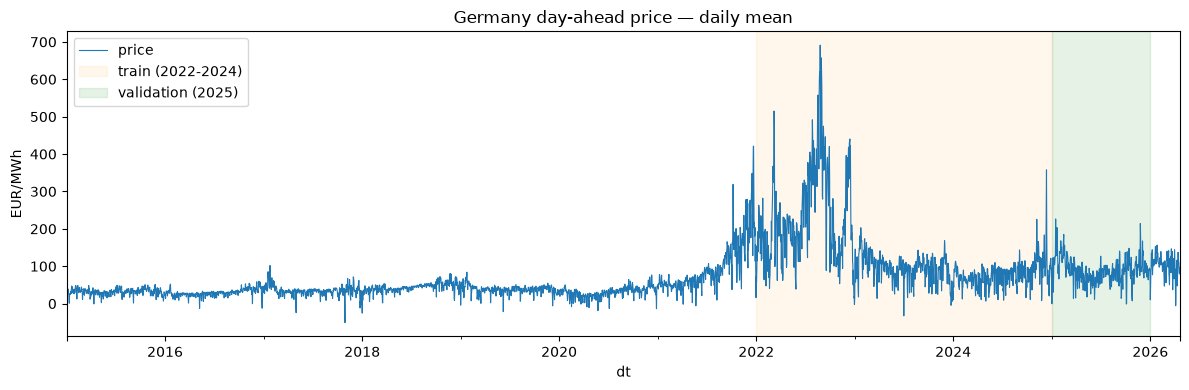

In [5]:
fig, ax = plt.subplots(figsize=(12, 4))
loader.df['price'].resample('D').mean().plot(ax=ax, lw=0.8)
ax.set_title('Germany day-ahead price — daily mean')
ax.set_ylabel('EUR/MWh')
ax.axvspan(pd.Timestamp('2022-01-01'), pd.Timestamp('2025-01-01'), color='orange', alpha=0.08, label='train (2022-2024)')
ax.axvspan(pd.Timestamp('2025-01-01'), pd.Timestamp('2026-01-01'), color='green', alpha=0.10, label='validation (2025)')
ax.legend()
plt.tight_layout()
plt.show()


**Note:** 2022 shows the European energy-crisis spike (very high mean and
volatility). It's kept in training deliberately — it's real data the deployed
policy might have to face again — but it's worth remembering when
interpreting training-set results, since it pulls the training mean price up
noticeably relative to validation.


## 3. Price distribution within the overnight charging window

The charging decision only ever happens during the arrival-to-07:00 window.
`loader.overnight_train_prices()` extracts exactly that slice — **training
data only**, so nothing here leaks information from the validation year.


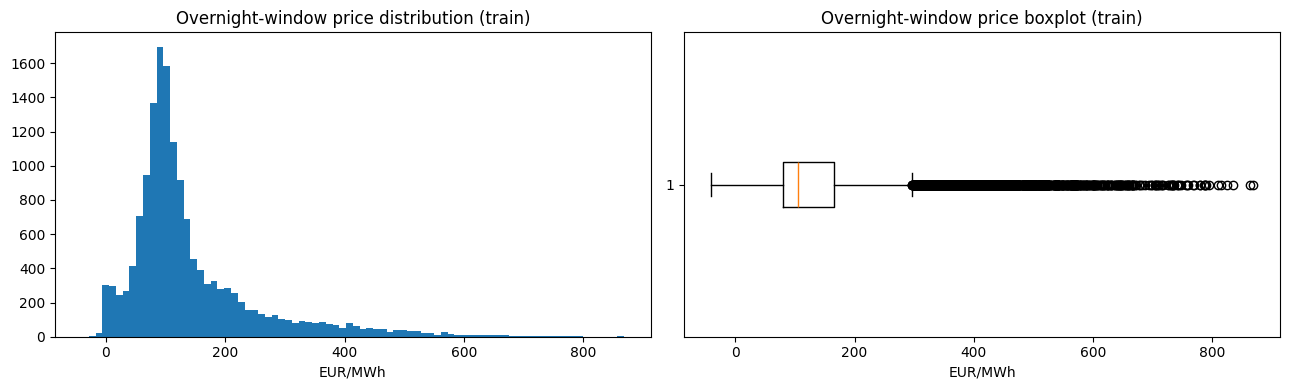

count    15344.000
mean       142.055
std        113.557
min        -40.140
25%         79.340
50%        105.865
75%        166.108
max        867.850
dtype: float64

In [5]:
overnight_prices = loader.overnight_train_prices()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(overnight_prices, bins=80)
axes[0].set_title('Overnight-window price distribution (train)')
axes[0].set_xlabel('EUR/MWh')

axes[1].boxplot(overnight_prices, vert=False, showfliers=True)
axes[1].set_title('Overnight-window price boxplot (train)')
axes[1].set_xlabel('EUR/MWh')
plt.tight_layout()
plt.show()

pd.Series(overnight_prices).describe()


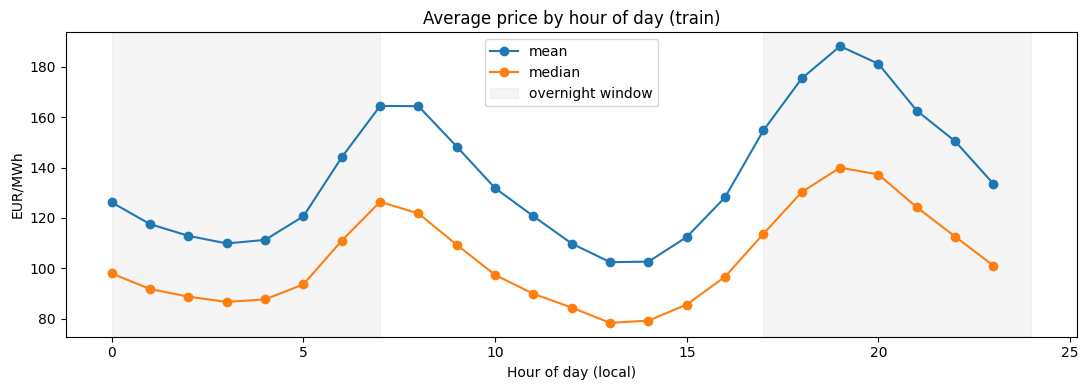

In [6]:
hourly_profile = (
    loader.train_df.assign(hour=loader.train_df.index.hour)
    .groupby('hour')['price'].agg(['mean', 'median'])
)
ax = hourly_profile.plot(marker='o', figsize=(11, 4))
ax.axvspan(17, 23.99, color='grey', alpha=0.08)
ax.axvspan(0, 7, color='grey', alpha=0.08, label='overnight window')
ax.set_xlabel('Hour of day (local)')
ax.set_ylabel('EUR/MWh')
ax.set_title('Average price by hour of day (train)')
ax.legend()
plt.tight_layout()
plt.show()


There's a clear evening peak (right when EVs typically arrive, 17:00-20:00),
a dip overnight, and a morning peak after the 07:00 deadline. This intraday
shape is *why* a price-aware policy should beat one that ignores price
entirely — there's a real, systematic pattern to exploit, not just noise.


## 4. Deriving the price bins

The environment discretizes price into bins using the `Quantizer` class —
the exact same class used inside `EVChargingEnvDiscrete` and by the trained
Q-learning agent. Fitting it here, on the same training-only overnight
prices, reproduces precisely the bin edges the environment actually uses.


In [7]:
price_quantizer = Quantizer(
    overnight_prices,
    num_bins=3,          # matches PRICE_N_BINS used throughout the project
    mode='percentile',   # tertiles: equal COUNT of hours per bin, not equal price range
    range_pct=100,
    log_scale=False,
)

print('Bin edges (EUR/MWh):', price_quantizer.edges.round(2))
print('Bin centers (EUR/MWh):', price_quantizer.centers.round(2))


Bin edges (EUR/MWh): [-40.14  88.33 135.02 867.85]
Bin centers (EUR/MWh): [ 24.1  111.67 501.43]


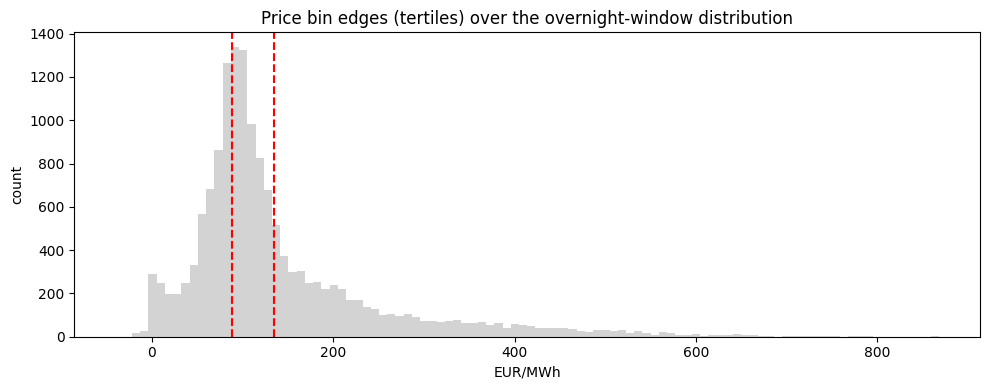

In [8]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(overnight_prices, bins=100, color='lightgrey')
for edge in price_quantizer.edges[1:-1]:
    ax.axvline(edge, color='red', ls='--', lw=1.5)
ax.set_title('Price bin edges (tertiles) over the overnight-window distribution')
ax.set_xlabel('EUR/MWh')
ax.set_ylabel('count')
plt.tight_layout()
plt.show()


**Why percentile (tertile) bins instead of equal-width bins?** Price is
heavily right-skewed (a long tail of expensive spike hours, visible in the
histogram above) — equal-width bins over that range would put almost every
hour in the same "low" bucket and leave the other bins nearly empty.
Percentile bins guarantee roughly equal *data* per bin, which is what a
tabular agent actually needs to learn each bin's behavior well.


## 5. The naive policy

`NaiveImmediateChargePolicy` — charge at full power the instant the car
arrives, ignoring price entirely, until the target SoC is reached. This is
the "dumbest reasonable" baseline: what anyone plugging in without thinking
about price would do. It requires no derivation from the data — it's
intentionally the price-blind reference point everything else must beat.


In [9]:
train_env, val_env = make_train_val_envs('Germany.csv', price_n_bins=3, soc_n_bins=10)

naive_policy = NaiveImmediateChargePolicy(train_env.quantizers['soc'], train_env.target_soc)
print('Naive policy: charges at full power whenever SoC bucket < target SoC bucket, regardless of price.')


Naive policy: charges at full power whenever SoC bucket < target SoC bucket, regardless of price.
